## **Import Libraries**

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC

from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import (
    RobustScaler
)

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

### **Load Baseline Dataset**

In [6]:
X_train_scaled = np.load(
    '../data/processed/X_train_scaled.npy'
)

X_test_scaled = np.load(
    '../data/processed/X_test_scaled.npy'
)

y_train = np.load(
    '../data/processed/y_train.npy'
)

y_test = np.load(
    '../data/processed/y_test.npy'
)

### **Load PCA Dataset**

In [ ]:
X_train_pca = np.load(
    '../data/processed/X_train_pca.npy'
)

X_test_pca = np.load(
    '../data/processed/X_test_pca.npy'
)

### **Load Engineered Dataset**

In [8]:
x_engineered_train = np.load(
    '../data/processed/x_engineered_train.npy'
)
x_engineered_test = np.load(
    '../data/processed/x_engineered_test.npy'
)

# **Pipeline**

## **Baseline Pipeline**

In [9]:
baseline_pipeline = Pipeline([

    ('scaler', RobustScaler()),

    ('svm', SVC())
])

## **PCA Pipeline**

In [10]:
pca_pipeline = Pipeline([

    ('scaler', RobustScaler()),

    ('pca', PCA()),

    ('svm', SVC())
])

## **Engineered Features Pipeline**

In [11]:
engineered_pipeline = Pipeline([

    ('scaler', RobustScaler()),

    ('svm', SVC())
])

# **Hyperparameter Tunning**

### **Hyperparameter Tunning Setup**

In [12]:
baseline_param_grid = {

    'svm__C': [0.1, 1, 10],

    'svm__gamma': ['scale', 0.1, 0.01],

    'svm__kernel': ['rbf']
}

In [13]:
pca_param_grid = {

    'pca__n_components': [0.90, 0.95],

    'svm__C': [0.1, 1, 10],

    'svm__gamma': ['scale', 0.1, 0.01],

    'svm__kernel': ['rbf']
}

In [14]:
engineered_param_grid = {

    'svm__C': [0.1, 1, 10],

    'svm__gamma': ['scale', 0.1, 0.01],

    'svm__kernel': ['rbf']
}

### **Cross Validation Strategy**

In [15]:
cv_strategy = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

## **Baseline SVM Tuning**

In [16]:
baseline_grid = GridSearchCV(

    estimator=baseline_pipeline,

    param_grid=baseline_param_grid,

    scoring='f1',

    cv=cv_strategy,

    n_jobs=-1
)

In [17]:
baseline_grid.fit(

    X_train_scaled,

    y_train
)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.1, ...], 'svm__kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,with_centering,True


In [18]:
baseline_grid.best_params_

{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

In [19]:
baseline_grid.best_score_

np.float64(0.4501945987794981)

## **PCA + SVM Tuning**

In [20]:
pca_grid = GridSearchCV(

    estimator=pca_pipeline,

    param_grid=pca_param_grid,

    scoring='f1',

    cv=cv_strategy,

    n_jobs=-1
)

In [32]:
pca_grid.fit(

    X_train_pca,

    y_train
)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'pca__n_components': [0.9, 0.95], 'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.1, ...], 'svm__kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,with_centering,True


In [22]:
pca_grid.best_params_

{'pca__n_components': 0.95,
 'svm__C': 10,
 'svm__gamma': 0.1,
 'svm__kernel': 'rbf'}

In [23]:
pca_grid.best_score_

np.float64(0.3858620146296191)

## **Engineered Features Tuning**

In [24]:
engineered_grid = GridSearchCV(

    estimator=engineered_pipeline,

    param_grid=engineered_param_grid,

    scoring='f1',

    cv=cv_strategy,

    n_jobs=-1
)

In [25]:
engineered_grid.fit(

    x_engineered_train,

    y_train
)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.1, ...], 'svm__kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,with_centering,True


In [26]:
engineered_grid.best_params_

{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

In [27]:
engineered_grid.best_score_

np.float64(0.41195462602662775)

# **Evaluation & Comparison**

## **Evaluation Function**

In [28]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_scores = model.decision_function(X_test)

    metrics = {

        'Accuracy':
        accuracy_score(y_test, y_pred),

        'Precision':
        precision_score(y_test, y_pred),

        'Recall':
        recall_score(y_test, y_pred),

        'F1_Score':
        f1_score(y_test, y_pred),

        'ROC_AUC':
        roc_auc_score(y_test, y_scores)
    }

    return metrics

## **Evaluate Baseline Model**

In [29]:
baseline_metrics = evaluate_model(

    baseline_grid.best_estimator_,

    X_test_scaled,

    y_test
)

pd.DataFrame(
    baseline_metrics,
    index=['Baseline SVM']
)

,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Baseline SVM,0.813667,0.656203,0.330821,0.43988,0.715667


### **Evaluate PCA Model**

In [33]:
pca_metrics = evaluate_model(

    pca_grid.best_estimator_,

    X_test_pca,

    y_test
)

pd.DataFrame(
    pca_metrics,
    index=['PCA + SVM']
)

,Accuracy,Precision,Recall,F1_Score,ROC_AUC
PCA + SVM,0.774667,0.234043,0.008289,0.016012,0.534537


### **Evaluate Engineered Models**

In [34]:
engineered_metrics = evaluate_model(

    engineered_grid.best_estimator_,

    x_engineered_test,

    y_test
)

pd.DataFrame(
    engineered_metrics,
    index=['Engineered Features + SVM']
)


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Engineered Features + SVM,0.8025,0.607576,0.302185,0.403624,0.69935


## **Final Comparison Table**

In [35]:
comparison_df = pd.DataFrame({

    'Model': [

        'Baseline SVM',

        'PCA + SVM',

        'Engineered Features + SVM'
    ],

    'Accuracy': [

        baseline_metrics['Accuracy'],

        pca_metrics['Accuracy'],

        engineered_metrics['Accuracy']
    ],

    'Precision': [

        baseline_metrics['Precision'],

        pca_metrics['Precision'],

        engineered_metrics['Precision']
    ],

    'Recall': [

        baseline_metrics['Recall'],

        pca_metrics['Recall'],

        engineered_metrics['Recall']
    ],

    'F1_Score': [

        baseline_metrics['F1_Score'],

        pca_metrics['F1_Score'],

        engineered_metrics['F1_Score']
    ],

    'ROC_AUC': [

        baseline_metrics['ROC_AUC'],

        pca_metrics['ROC_AUC'],

        engineered_metrics['ROC_AUC']
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Baseline SVM,0.813667,0.656203,0.330821,0.439880,0.715667
1,PCA + SVM,0.774667,0.234043,0.008289,0.016012,0.534537
2,Engineered Features + SVM,0.802500,0.607576,0.302185,0.403624,0.699350


##  **Highlight Best Scores**

In [36]:
comparison_df.style.highlight_max(

    subset=[

        'Accuracy',

        'Precision',

        'Recall',

        'F1_Score',

        'ROC_AUC'
    ],

    color='lightgreen'
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Baseline SVM,0.813667,0.656203,0.330821,0.439880,0.715667
1,PCA + SVM,0.774667,0.234043,0.008289,0.016012,0.534537
2,Engineered Features + SVM,0.802500,0.607576,0.302185,0.403624,0.699350


## **Models Performance Visualization**

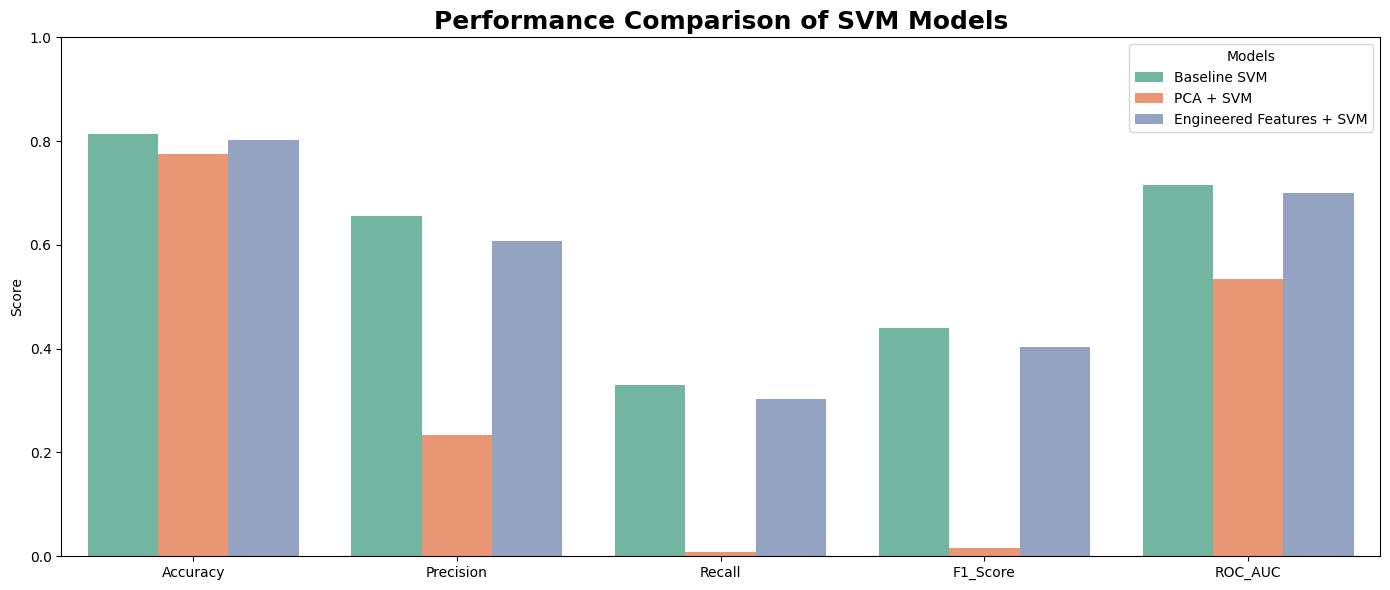

In [37]:
comparison_melted = comparison_df.melt(

    id_vars='Model',

    var_name='Metric',

    value_name='Score'
)


plt.figure(figsize=(14,6))

sns.barplot(

    data=comparison_melted,

    x='Metric',

    y='Score',

    hue='Model',

    palette='Set2'
)

plt.title(

    'Performance Comparison of SVM Models',

    fontsize=18,

    fontweight='bold'
)

plt.xlabel('')

plt.ylabel('Score')

plt.ylim(0,1)

plt.legend(title='Models')

plt.tight_layout()

plt.show()

## **Best Model Selection**

In [38]:
best_model_name = comparison_df.loc[

    comparison_df['F1_Score'].idxmax(),

    'Model'
]

print(
    f'Best Performing Model: {best_model_name}'
)

Best Performing Model: Baseline SVM


# **Final Selected Pipeline**

In [39]:
final_pipeline = baseline_grid.best_estimator_

final_X_test = X_test_scaled

final_y_test = y_test

## **Final Predictions**

In [40]:
final_predictions = final_pipeline.predict(
    final_X_test
)

## Confusion Matrix

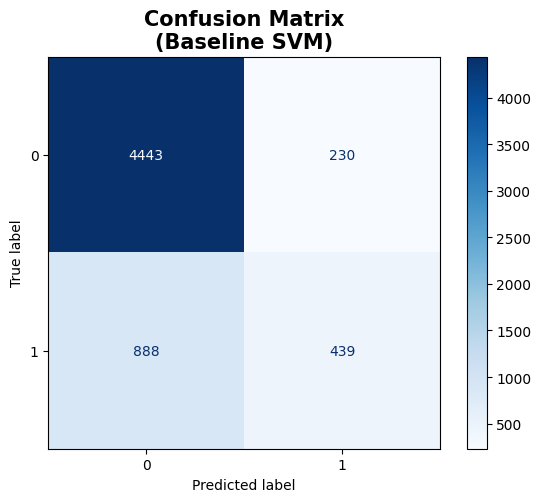

In [41]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    final_y_test,

    final_predictions,

    cmap='Blues',

    ax=ax
)

plt.title(

    f'Confusion Matrix\n({best_model_name})',

    fontsize=15,

    fontweight='bold'
)

plt.tight_layout()

plt.show()

## **Classification Report**

In [42]:
print(

    classification_report(

        final_y_test,

        final_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.66      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



## **Save Tuned Pipelines**

In [43]:
joblib.dump(

    baseline_grid.best_estimator_,

    '../artifacts/tuned_baseline_pipeline.pkl'
)

joblib.dump(

    pca_grid.best_estimator_,

    '../artifacts/tuned_pca_pipeline.pkl'
)

joblib.dump(

    engineered_grid.best_estimator_,

    '../artifacts/tuned_engineered_pipeline.pkl'
)


joblib.dump(

    final_pipeline,

    '../artifacts/final_pipeline.pkl'
)

['../artifacts/final_pipeline.pkl']